# 条件概率与贝叶斯公式 - 可视化

本 Notebook 生成三张图：
1. 条件概率样本空间切分
2. 先验-似然-后验流程图
3. 基准率对后验概率的影响曲线

输出目录：`assets/`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path

assets_dir = Path.cwd() / 'assets'
assets_dir.mkdir(parents=True, exist_ok=True)
assets_dir

WindowsPath('D:/BBFEC-FRONT/RL-AND-RL/01_数学基础/03_概率统计/assets')

## 图1：条件概率样本空间切分

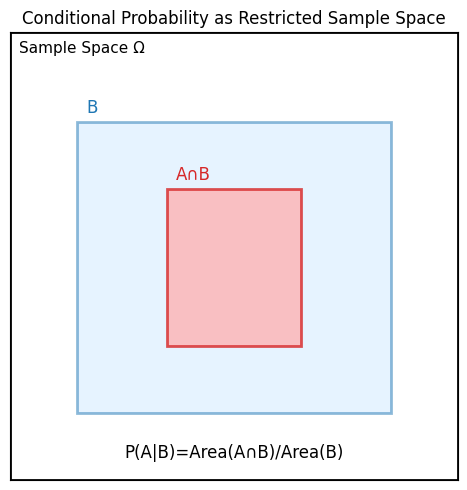

In [2]:
# 用矩形面积示意 P(A|B) = P(A∩B)/P(B)
fig, ax = plt.subplots(figsize=(7,5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')

# 全空间
ax.add_patch(Rectangle((0,0),1,1, fill=False, linewidth=2, edgecolor='black'))

# B区域
Bx, By, Bw, Bh = 0.15, 0.15, 0.7, 0.65
ax.add_patch(Rectangle((Bx,By),Bw,Bh, facecolor='#cfe8ff', alpha=0.5, edgecolor='tab:blue', linewidth=2))

# A∩B区域
Ix, Iy, Iw, Ih = 0.35, 0.30, 0.3, 0.35
ax.add_patch(Rectangle((Ix,Iy),Iw,Ih, facecolor='#ffb3b3', alpha=0.8, edgecolor='tab:red', linewidth=2))

ax.text(0.02, 0.98, 'Sample Space Ω', va='top', fontsize=11)
ax.text(Bx+0.02, By+Bh+0.02, 'B', color='tab:blue', fontsize=12)
ax.text(Ix+0.02, Iy+Ih+0.02, 'A∩B', color='tab:red', fontsize=12)
ax.text(0.5, 0.05, 'P(A|B)=Area(A∩B)/Area(B)', ha='center', fontsize=12)

ax.set_xticks([]); ax.set_yticks([])
plt.title('Conditional Probability as Restricted Sample Space')
plt.tight_layout()
plt.savefig(assets_dir / '28_conditional_probability_space.png', dpi=160)
plt.show()

## 图2：贝叶斯更新流程

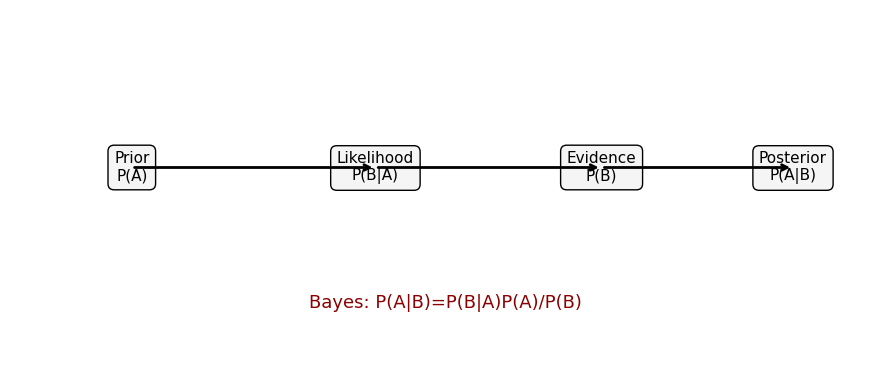

In [3]:
fig, ax = plt.subplots(figsize=(9,3.8))
ax.axis('off')

nodes = {
    'Prior\nP(A)': (0.14, 0.55),
    'Likelihood\nP(B|A)': (0.42, 0.55),
    'Evidence\nP(B)': (0.68, 0.55),
    'Posterior\nP(A|B)': (0.90, 0.55),
}

for label, (x, y) in nodes.items():
    ax.text(x, y, label, ha='center', va='center', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.4', fc='#f5f5f5', ec='black'))

arr = dict(arrowstyle='->', lw=2)
ax.annotate('', xy=nodes['Likelihood\nP(B|A)'], xytext=nodes['Prior\nP(A)'], arrowprops=arr)
ax.annotate('', xy=nodes['Evidence\nP(B)'], xytext=nodes['Likelihood\nP(B|A)'], arrowprops=arr)
ax.annotate('', xy=nodes['Posterior\nP(A|B)'], xytext=nodes['Evidence\nP(B)'], arrowprops=arr)

ax.text(0.5, 0.15, 'Bayes: P(A|B)=P(B|A)P(A)/P(B)', ha='center', color='darkred', fontsize=13)
plt.tight_layout()
plt.savefig(assets_dir / '29_bayes_update_flow.png', dpi=160)
plt.show()

## 图3：基准率对后验的影响

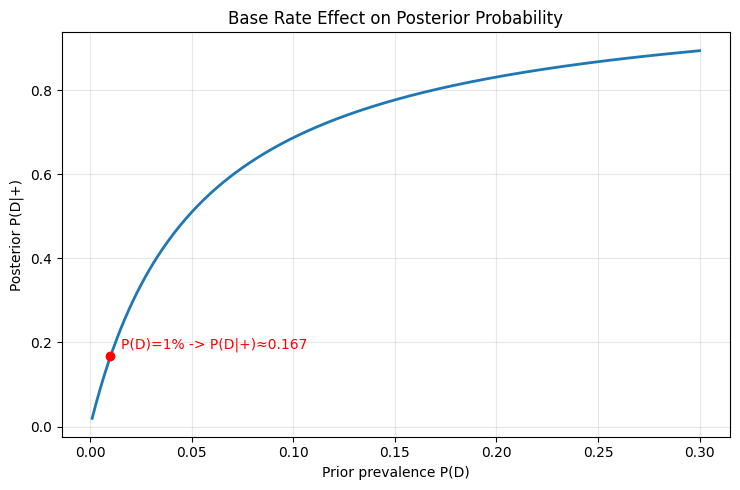

In [4]:
# 固定检测性能
sens = 0.99   # P(+|D)
fpr = 0.05    # P(+|not D)

priors = np.linspace(0.001, 0.3, 300)
post = (sens * priors) / (sens * priors + fpr * (1 - priors))

plt.figure(figsize=(7.5,5))
plt.plot(priors, post, linewidth=2)
plt.xlabel('Prior prevalence P(D)')
plt.ylabel('Posterior P(D|+)')
plt.title('Base Rate Effect on Posterior Probability')
plt.grid(alpha=0.3)

# 标注 1% 基准率点
p0 = 0.01
post0 = (sens*p0)/(sens*p0 + fpr*(1-p0))
plt.scatter([p0], [post0], c='red', zorder=5)
plt.text(p0+0.005, post0+0.02, f'P(D)=1% -> P(D|+)≈{post0:.3f}', color='red')

plt.tight_layout()
plt.savefig(assets_dir / '30_base_rate_effect.png', dpi=160)
plt.show()

### 输出文件
- `assets/28_conditional_probability_space.png`
- `assets/29_bayes_update_flow.png`
- `assets/30_base_rate_effect.png`